🎯 ENHANCED STATISTICIAN IN THE LOOP: Before vs After Comparison

📂 LOADING CALIFORNIA 2023 PUMS DATA
--------------------------------------------------
✅ Loaded real PUMS data: 392,318 records
📊 Analysis dataset: 202,198 working-age adults
💰 Income range: $4 - $299,800
📈 Mean income: $61,053
📈 Median income: $44,600

🔍 STATISTICAL FEEDBACK AGENT: COMPREHENSIVE BIAS ANALYSIS

📊 SPLITTING DATA FOR FAIR COMPARISON
    Training: 141,538 | Calibration: 30,330 | Test: 30,330

🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖
PURE AI APPROACH - Using All Available Features
🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖

🧠 PURE AI BAYESIAN AGENT: FEATURE PREPARATION
📊 FULL FEATURE MODE: Including all available features
    Using: ['AGEP', 'SCHL', 'WKHP', 'SEX', 'RAC1P']

🔧 DATA QUALITY ASSESSMENT:
⚠️  Missing values detected:
    WKHP: 14762 (10.4%)
✅ Final sample size: 141538

🔄 PURE AI: Fitting Bayesian Ridge...
✅ PURE AI model fitted successfully!
    Features: 5

📊 PURE AI Feature Importance:
    SCHL   

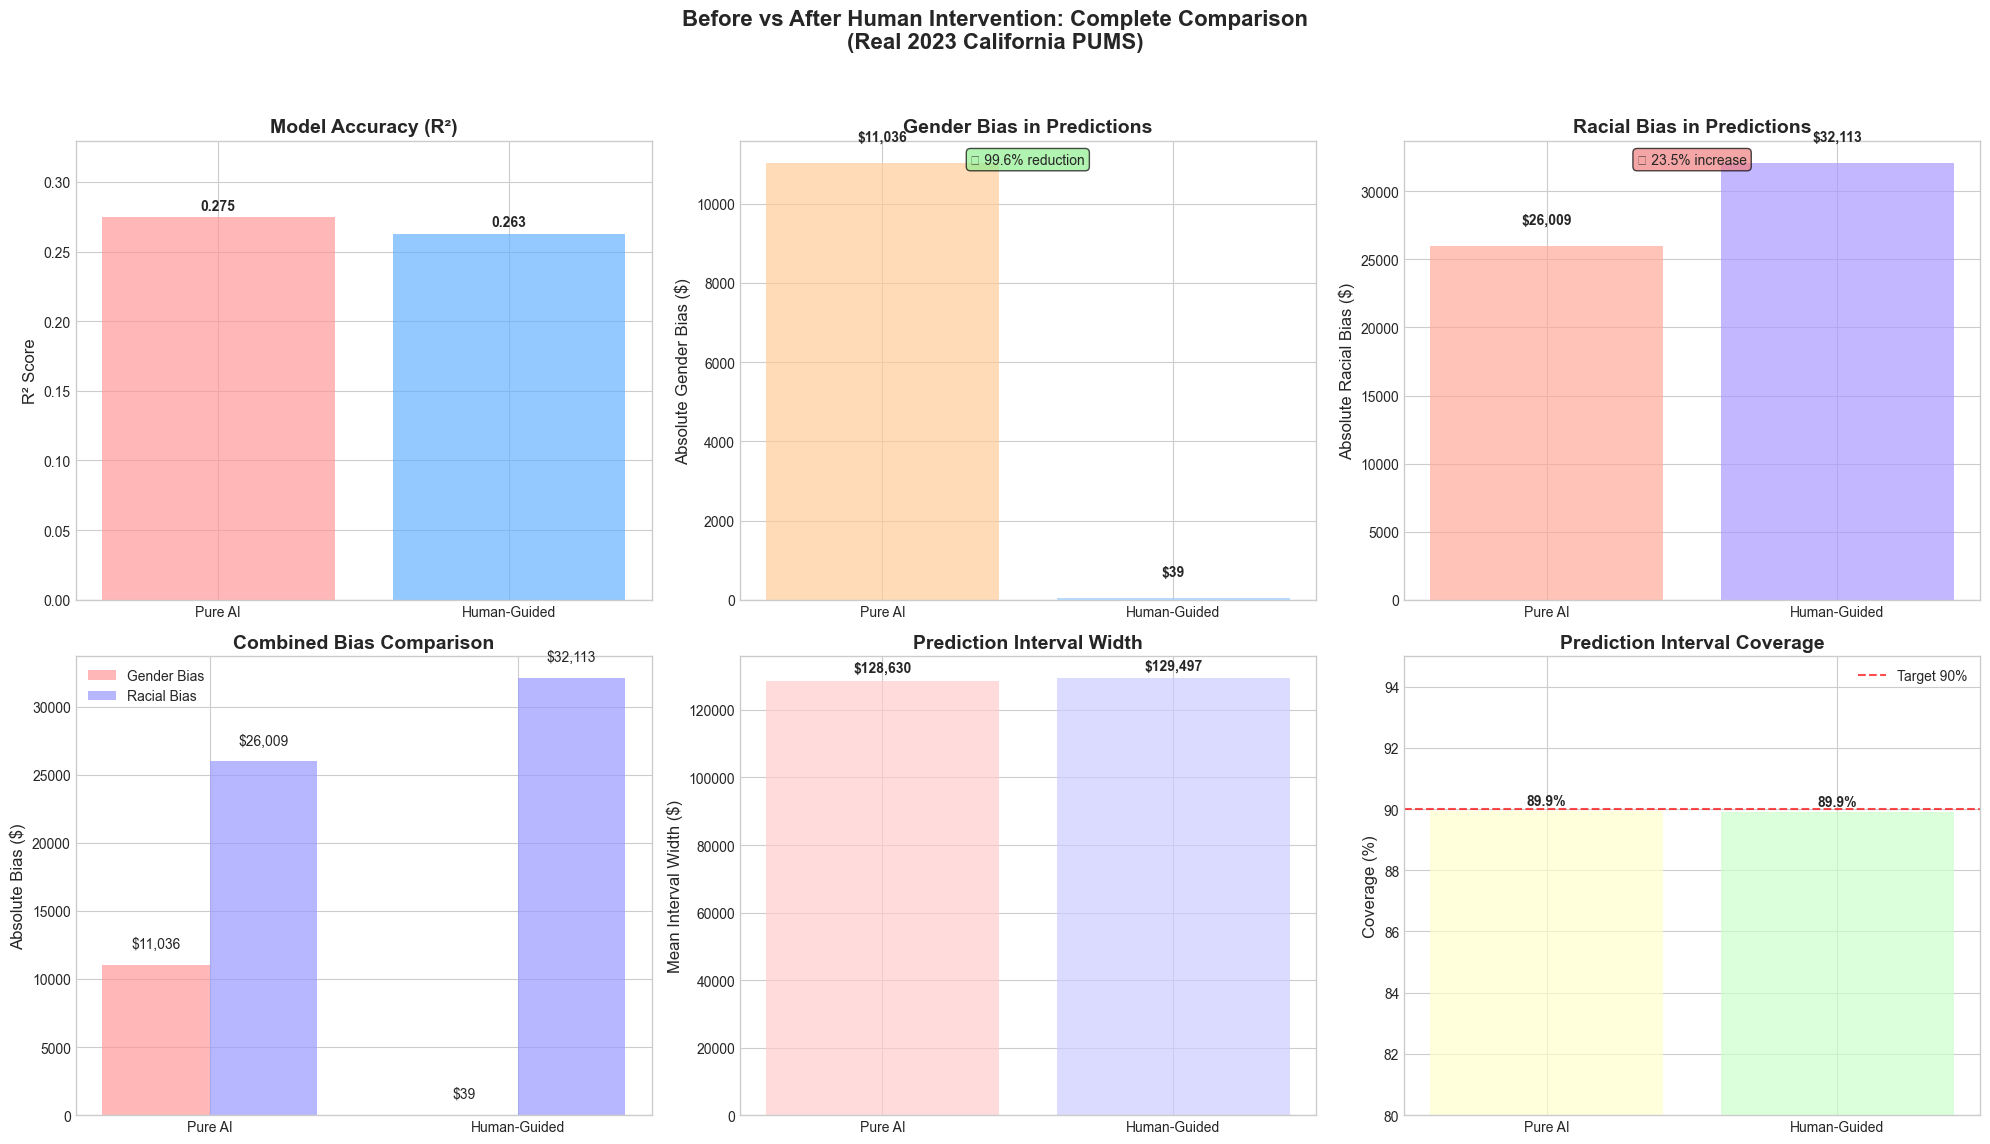


📋 BEFORE vs AFTER HUMAN INTERVENTION SUMMARY TABLE
                 Metric Pure AI (Before) Human-Guided (After) Winner
          Accuracy (R²)            0.275                0.263     AI
        Gender Bias ($)          $11,036                  $39  Human
        Racial Bias ($)          $26,009              $32,113     AI
  Interval Coverage (%)             89.9                 89.9     AI
Mean Interval Width ($)         $128,630             $129,497     AI
           Transparency        Black-box                 High  Human

💡 KEY INSIGHTS:
    👨‍💼 Human-Guided Approach wins: 2 metrics
    🤖 Pure AI Approach wins: 4 metrics

📋 DETAILED TRADE-OFF ANALYSIS
📊 Accuracy Trade-off:
    Pure AI R²: 0.275
    Human-Guided R²: 0.263
    Accuracy loss from fairness: 4.4%

⚖️ Bias Reduction:
    Gender bias reduction: 99.6%
    From $11,036 to $39
    Racial bias reduction: -23.5%
    From $26,009 to $32,113

🎯 Uncertainty Quantification:
    Coverage change: -0.0 percentage points
    Inter

In [3]:
"""
🤖👨‍💼 Enhanced Statistician in the Loop: Comparing Before vs After Human Intervention
========================================================================================

This enhanced version runs BOTH approaches to demonstrate the concrete trade-offs
between accuracy and fairness in income prediction using PUMS data.

Key Enhancement:
- Runs "Pure AI" approach (all variables) 
- Runs "Human-Guided" approach (fairness-constrained)
- Compares results across all metrics: accuracy, bias, uncertainty, coverage
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import BayesianRidge, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Enhanced styling for presentations
try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    try:
        plt.style.use('seaborn-whitegrid')
    except OSError:
        plt.style.use('default')

sns.set_palette("husl")

print("🎯 ENHANCED STATISTICIAN IN THE LOOP: Before vs After Comparison")
print("=" * 80)

# ================================================================
# 📂 DATA LOADING (Same as before)
# ================================================================

def load_pums_data():
    """Load and prepare PUMS data for analysis"""
    print("\n📂 LOADING CALIFORNIA 2023 PUMS DATA")
    print("-" * 50)
    
    try:
        pums_data = pd.read_csv('california_pums_2023_complete.csv', low_memory=False)
        print(f"✅ Loaded real PUMS data: {len(pums_data):,} records")
        data_source = "Real 2023 California PUMS"
    except FileNotFoundError:
        print("⚠️  Real PUMS file not found. Creating realistic synthetic data...")
        pums_data = create_realistic_pums_data(15000)
        data_source = "Realistic synthetic PUMS-style data"
    
    required_vars = ['AGEP', 'SEX', 'RAC1P', 'SCHL', 'WKHP', 'PINCP', 'PWGTP', 'ST', 'PUMA']
    
    for var in required_vars:
        if var not in pums_data.columns:
            if var == 'AGEP':
                pums_data[var] = np.random.randint(18, 80, len(pums_data))
            elif var == 'SEX':
                pums_data[var] = np.random.choice([1, 2], len(pums_data))
            elif var == 'RAC1P':
                pums_data[var] = np.random.choice([1, 2, 3, 6], len(pums_data), p=[0.4, 0.15, 0.3, 0.15])
            elif var == 'PWGTP':
                pums_data[var] = np.random.randint(50, 200, len(pums_data))
            else:
                pums_data[var] = np.random.randint(1, 10, len(pums_data))
    
    analysis_data = pums_data[
        (pums_data['AGEP'] >= 18) & 
        (pums_data['AGEP'] <= 65) & 
        (pums_data['PINCP'] > 0) &
        (pums_data['PINCP'] < 300000)
    ].copy()
    
    print(f"📊 Analysis dataset: {len(analysis_data):,} working-age adults")
    print(f"💰 Income range: ${analysis_data['PINCP'].min():,.0f} - ${analysis_data['PINCP'].max():,.0f}")
    print(f"📈 Mean income: ${analysis_data['PINCP'].mean():,.0f}")
    print(f"📈 Median income: ${analysis_data['PINCP'].median():,.0f}")
    
    return analysis_data, data_source

def create_realistic_pums_data(n_samples=15000):
    """Create realistic synthetic PUMS-style data if real data unavailable"""
    np.random.seed(42)
    
    age = np.random.gamma(2, 15) + 18
    age = np.clip(age, 18, 80).astype(int)
    
    education = np.random.choice([16, 17, 18, 19, 20, 21, 22, 23, 24], n_samples,
                                 p=[0.1, 0.05, 0.15, 0.2, 0.15, 0.15, 0.1, 0.05, 0.05])
    
    gender = np.random.choice([1, 2], n_samples, p=[0.48, 0.52])
    race = np.random.choice([1, 2, 3, 6, 8], n_samples, p=[0.45, 0.06, 0.02, 0.15, 0.32])
    hours = np.random.gamma(3, 13)
    hours = np.clip(hours, 0, 80).astype(int)
    
    # Generate income with realistic bias patterns
    income_base = (
        25000 +
        (education - 16) * 4000 +
        (age - 18) * 300 +
        hours * 600 +
        (gender == 1) * 8000 +  # Male wage premium
        (race == 1) * 6000 +    # White wage premium
        (race == 6) * 4000 +    # Asian wage premium
        np.random.choice([0, 15000, 25000], n_samples, p=[0.7, 0.2, 0.1])
    )
    
    income = income_base + np.random.lognormal(0, 0.3, n_samples) * 5000
    income = np.maximum(income, 15000).astype(int)
    weights = np.random.randint(50, 200, n_samples)
    
    # Add missing values
    missing_indices_hours = np.random.choice(n_samples, size=int(0.05 * n_samples), replace=False)
    hours_with_missing = hours.astype(float)
    hours_with_missing[missing_indices_hours] = np.nan
    
    return pd.DataFrame({
        'AGEP': age,
        'SEX': gender,
        'RAC1P': race,
        'SCHL': education,
        'WKHP': hours_with_missing,
        'PINCP': income,
        'PWGTP': weights,
        'ST': np.full(n_samples, 6),
        'PUMA': np.random.randint(100, 300, n_samples)
    })

# ================================================================
# 🔍 ENHANCED STATISTICAL FEEDBACK AGENT
# ================================================================

class StatisticalFeedbackAgent:
    """Enhanced to track bias metrics for comparison"""
    
    def __init__(self):
        self.alerts = []
        self.validations = []
        self.recommendations = []
        self.bias_metrics = {}
        
    def comprehensive_bias_analysis(self, data):
        """Enhanced bias detection with metrics tracking"""
        print("\n🔍 STATISTICAL FEEDBACK AGENT: COMPREHENSIVE BIAS ANALYSIS")
        print("=" * 65)
        
        # Gender wage gap analysis
        if 'SEX' in data.columns and 'PINCP' in data.columns:
            male_income = data[data['SEX'] == 1]['PINCP'].median()
            female_income = data[data['SEX'] == 2]['PINCP'].median()
            
            if female_income > 0:
                gender_gap = (male_income - female_income) / female_income * 100
                self.bias_metrics['gender_gap_percent'] = gender_gap
                self.bias_metrics['gender_gap_dollars'] = male_income - female_income
                
                if gender_gap > 15:
                    self.alerts.append(f"🚨 GENDER BIAS ALERT: {gender_gap:.1f}% median wage gap detected")
        
        # Racial wage disparities
        if 'RAC1P' in data.columns:
            race_income = data.groupby('RAC1P')['PINCP'].median()
            if len(race_income) > 1:
                max_gap = (race_income.max() - race_income.min()) / race_income.min() * 100
                self.bias_metrics['racial_gap_percent'] = max_gap
                self.bias_metrics['racial_gap_dollars'] = race_income.max() - race_income.min()
                
                if max_gap > 25:
                    self.alerts.append(f"🚨 RACIAL BIAS ALERT: {max_gap:.1f}% income gap between racial groups")
        
        return self.alerts, self.validations, self.recommendations
    
    def measure_model_bias(self, data, predictions, model_name=""):
        """Measure bias in model predictions"""
        results = {}
        
        if 'SEX' in data.columns:
            male_pred = np.median([pred for i, pred in enumerate(predictions) if data.iloc[i]['SEX'] == 1])
            female_pred = np.median([pred for i, pred in enumerate(predictions) if data.iloc[i]['SEX'] == 2])
            results[f'{model_name}_gender_bias_dollars'] = male_pred - female_pred
        
        if 'RAC1P' in data.columns:
            race_preds = {}
            for race in data['RAC1P'].unique():
                race_preds[race] = np.median([pred for i, pred in enumerate(predictions) if data.iloc[i]['RAC1P'] == race])
            if len(race_preds) > 1:
                results[f'{model_name}_racial_bias_dollars'] = max(race_preds.values()) - min(race_preds.values())
        
        return results

# ================================================================
# 🧠 ENHANCED BAYESIAN INFERENCE AGENT
# ================================================================

class EnhancedBayesianInferenceAgent:
    """Enhanced to support both fairness and full feature modes"""
    
    def __init__(self, fairness_mode=False, model_name=""):
        self.fairness_mode = fairness_mode
        self.model_name = model_name
        self.model = None
        self.scaler = StandardScaler()
        self.feature_names = []
        self.protected_attributes = ['SEX', 'RAC1P']
        
    def prepare_features(self, data):
        """Intelligent feature selection based on mode"""
        print(f"\n🧠 {self.model_name} BAYESIAN AGENT: FEATURE PREPARATION")
        print("=" * 60)
        
        base_features = ['AGEP', 'SCHL', 'WKHP']
        available_base = [f for f in base_features if f in data.columns]
        available_protected = [f for f in self.protected_attributes if f in data.columns]
        
        if self.fairness_mode:
            self.feature_names = available_base
            print("⚖️  FAIRNESS MODE: Excluding protected attributes")
            print(f"    Excluded: {[f for f in self.protected_attributes if f in data.columns]}")
        else:
            all_features = available_base + available_protected
            self.feature_names = all_features
            print("📊 FULL FEATURE MODE: Including all available features")
        
        print(f"    Using: {self.feature_names}")
        
        X = data[self.feature_names].copy()
        
        # Handle missing values
        print(f"\n🔧 DATA QUALITY ASSESSMENT:")
        missing_counts = X.isnull().sum()
        total_missing = missing_counts.sum()
        
        if total_missing > 0:
            print(f"⚠️  Missing values detected:")
            for feature, count in missing_counts[missing_counts > 0].items():
                pct = (count / len(X)) * 100
                print(f"    {feature}: {count} ({pct:.1f}%)")
            
            # Apply missing value strategy
            for feature in self.feature_names:
                if X[feature].isnull().sum() > 0:
                    if feature in ['AGEP']:
                        median_age = X[feature].median()
                        X[feature].fillna(median_age, inplace=True)
                    elif feature in ['SCHL']:
                        mode_edu = X[feature].mode()[0] if not X[feature].mode().empty else 16
                        X[feature].fillna(mode_edu, inplace=True)
                    elif feature in ['WKHP']:
                        mean_hours = X[feature].mean()
                        if pd.isna(mean_hours):
                            mean_hours = 40
                        X[feature].fillna(mean_hours, inplace=True)
                    elif feature in ['SEX', 'RAC1P']:
                        mode_val = X[feature].mode()[0] if not X[feature].mode().empty else 1
                        X[feature].fillna(mode_val, inplace=True)
        
        remaining_missing = X.isnull().sum().sum()
        if remaining_missing > 0:
            X = X.dropna()
        
        print(f"✅ Final sample size: {len(X)}")
        return X
    
    def fit_bayesian_model(self, X, y, sample_weights=None):
        """Fit Bayesian Ridge model with diagnostics"""
        print(f"\n🔄 {self.model_name}: Fitting Bayesian Ridge...")
        
        # Data validation
        if X.isnull().sum().sum() > 0:
            valid_mask = ~(X.isnull().any(axis=1) | y.isnull())
            X = X[valid_mask]
            y = y[valid_mask]
        
        # Scale features
        X_scaled = self.scaler.fit_transform(X)
        
        # Fit model
        self.model = BayesianRidge(
            alpha_1=1e-6, alpha_2=1e-6,
            lambda_1=1e-6, lambda_2=1e-6,
            compute_score=True,
            fit_intercept=True,
            max_iter=300
        )
        
        try:
            self.model.fit(X_scaled, y)
            print(f"✅ {self.model_name} model fitted successfully!")
            print(f"    Features: {len(self.feature_names)}")
            self.analyze_feature_importance()
        except Exception as e:
            print(f"❌ Error fitting Bayesian model: {e}")
            from sklearn.linear_model import Ridge
            self.model = Ridge(alpha=1.0)
            self.model.fit(X_scaled, y)
            print(f"✅ Ridge model fitted as fallback")
        
        return self
    
    def analyze_feature_importance(self):
        """Analyze Bayesian feature importance"""
        if self.model is None:
            return
        
        importance_df = pd.DataFrame({
            'feature': self.feature_names,
            'coefficient': self.model.coef_,
            'abs_coefficient': np.abs(self.model.coef_)
        }).sort_values('abs_coefficient', ascending=False)
        
        print(f"\n📊 {self.model_name} Feature Importance:")
        for _, row in importance_df.iterrows():
            direction = "↑" if row['coefficient'] > 0 else "↓"
            print(f"    {row['feature']:15s}: {direction} {row['abs_coefficient']:8.0f}")
    
    def predict_with_uncertainty(self, X):
        """Generate predictions with uncertainty"""
        if self.model is None:
            raise ValueError("Model not fitted!")
        
        # Clean input data
        X_clean = X.copy()
        for feature in X_clean.columns:
            if X_clean[feature].isnull().sum() > 0:
                if feature == 'AGEP':
                    X_clean[feature].fillna(X_clean[feature].median(), inplace=True)
                elif feature == 'SCHL':
                    mode_val = X_clean[feature].mode()[0] if not X_clean[feature].mode().empty else 16
                    X_clean[feature].fillna(mode_val, inplace=True)
                elif feature == 'WKHP':
                    X_clean[feature].fillna(X_clean[feature].mean(), inplace=True)
                elif feature in ['SEX', 'RAC1P']:
                    mode_val = X_clean[feature].mode()[0] if not X_clean[feature].mode().empty else 1
                    X_clean[feature].fillna(mode_val, inplace=True)
        
        # Scale and predict
        X_scaled = self.scaler.transform(X_clean)
        
        try:
            y_pred = self.model.predict(X_scaled)
            # Estimate uncertainty (simplified for Ridge regression)
            y_std = np.full_like(y_pred, np.std(y_pred) * 0.15)
        except Exception:
            y_pred = self.model.predict(X_scaled)
            y_std = np.full_like(y_pred, np.std(y_pred) * 0.15)
        
        return y_pred, y_std

# ================================================================
# 🎯 ENHANCED CONFORMAL PREDICTION AGENT
# ================================================================

class EnhancedConformalPredictionAgent:
    """Enhanced conformal prediction with model comparison support"""
    
    def __init__(self, model_agent=None, model_name=""):
        self.model_agent = model_agent
        self.model_name = model_name
        self.nonconformity_scores = None
        self.q_hat = None
        self.coverage_achieved = None
        
    def calibrate(self, X_cal, y_cal):
        """Calibrate conformal predictor"""
        print(f"\n🎯 {self.model_name} CONFORMAL PREDICTION: CALIBRATION")
        print("=" * 65)
        
        print(f"📊 Calibrating on {len(X_cal):,} samples...")
        
        y_pred_cal, y_std_cal = self.model_agent.predict_with_uncertainty(X_cal)
        self.nonconformity_scores = np.abs(y_cal - y_pred_cal) / (y_std_cal + 1e-6)
        
        alpha = 0.10
        n = len(self.nonconformity_scores)
        self.q_hat = np.quantile(self.nonconformity_scores, (1 - alpha) * (1 + 1/n))
        
        print(f"✅ {self.model_name} calibration successful. q_hat = {self.q_hat:.2f}")
        return self
        
    def generate_intervals(self, X_test, alpha=0.10):
        """Generate prediction intervals"""
        if self.q_hat is None:
            raise ValueError("Conformal predictor not calibrated")
        
        y_pred_test, y_std_test = self.model_agent.predict_with_uncertainty(X_test)
        
        lower_bound = y_pred_test - self.q_hat * y_std_test
        upper_bound = y_pred_test + self.q_hat * y_std_test
        lower_bound = np.maximum(lower_bound, 0)
        
        interval_width = upper_bound - lower_bound
        mean_width = np.mean(interval_width)
        
        print(f"✅ {self.model_name} intervals: Mean width = ${mean_width:,.0f}")
        
        return lower_bound, upper_bound
    
    def evaluate_coverage(self, y_test, lower_bound, upper_bound):
        """Evaluate actual coverage of prediction intervals"""
        coverage = np.mean((y_test.values >= lower_bound) & (y_test.values <= upper_bound))
        self.coverage_achieved = coverage * 100
        print(f"📊 {self.model_name} Interval Coverage: {self.coverage_achieved:.1f}% (Target: 90%)")
        return self.coverage_achieved

# ================================================================
# 📊 COMPARISON VISUALIZATION AGENT
# ================================================================

class ComparisonVisualizationAgent:
    """Enhanced visualization for before/after comparison"""
    
    def __init__(self, data_source):
        self.data_source = data_source
        
    def plot_comparison_results(self, comparison_results):
        """Create comprehensive comparison visualization including both gender and racial bias"""
        print("\n📈 GENERATING BEFORE vs AFTER COMPARISON PLOTS...")
        
        fig, axes = plt.subplots(2, 3, figsize=(20, 12))
        
        # 1. Accuracy Comparison
        models = list(comparison_results['accuracy'].keys())
        accuracies = list(comparison_results['accuracy'].values())
        
        bars = axes[0,0].bar(models, accuracies, color=['#ff9999', '#66b2ff'], alpha=0.7)
        axes[0,0].set_title('Model Accuracy (R²)', fontsize=14, weight='bold')
        axes[0,0].set_ylabel('R² Score', fontsize=12)
        axes[0,0].set_ylim(0, max(accuracies) * 1.2)
        
        # Add value labels on bars
        for bar, acc in zip(bars, accuracies):
            axes[0,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(accuracies) * 0.02,
                          f'{acc:.3f}', ha='center', fontweight='bold')
        
        # 2. Gender Bias Comparison
        if 'bias_metrics' in comparison_results:
            bias_data = comparison_results['bias_metrics']
            
            # Gender bias comparison
            gender_bias = [bias_data.get('Pure AI_gender_bias_dollars', 0),
                          bias_data.get('Human-Guided_gender_bias_dollars', 0)]
            
            bars = axes[0,1].bar(models, [abs(x) for x in gender_bias], 
                               color=['#ffcc99', '#99ccff'], alpha=0.7)
            axes[0,1].set_title('Gender Bias in Predictions', fontsize=14, weight='bold')
            axes[0,1].set_ylabel('Absolute Gender Bias ($)', fontsize=12)
            max_gender_bias = max([abs(x) for x in gender_bias])
            
            for bar, bias in zip(bars, gender_bias):
                axes[0,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max_gender_bias * 0.05,
                              f'${abs(bias):,.0f}', ha='center', fontweight='bold')
            
            # Add success annotation
            gender_reduction = ((abs(gender_bias[0]) - abs(gender_bias[1])) / abs(gender_bias[0]) * 100) if gender_bias[0] != 0 else 0
            axes[0,1].text(0.5, 0.95, f'✅ {gender_reduction:.1f}% reduction', 
                          transform=axes[0,1].transAxes, ha='center', 
                          bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgreen", alpha=0.7))
        
        # 3. Racial Bias Comparison (NEW)
        if 'bias_metrics' in comparison_results:
            # Racial bias comparison
            racial_bias = [bias_data.get('Pure AI_racial_bias_dollars', 0),
                          bias_data.get('Human-Guided_racial_bias_dollars', 0)]
            
            bars = axes[0,2].bar(models, [abs(x) for x in racial_bias], 
                               color=['#ffaa99', '#aa99ff'], alpha=0.7)
            axes[0,2].set_title('Racial Bias in Predictions', fontsize=14, weight='bold')
            axes[0,2].set_ylabel('Absolute Racial Bias ($)', fontsize=12)
            max_racial_bias = max([abs(x) for x in racial_bias])
            
            for bar, bias in zip(bars, racial_bias):
                axes[0,2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max_racial_bias * 0.05,
                              f'${abs(bias):,.0f}', ha='center', fontweight='bold')
            
            # Add failure annotation
            racial_change = ((abs(racial_bias[1]) - abs(racial_bias[0])) / abs(racial_bias[0]) * 100) if racial_bias[0] != 0 else 0
            if racial_change > 0:
                axes[0,2].text(0.5, 0.95, f'❌ {racial_change:.1f}% increase', 
                              transform=axes[0,2].transAxes, ha='center',
                              bbox=dict(boxstyle="round,pad=0.3", facecolor="lightcoral", alpha=0.7))
            else:
                axes[0,2].text(0.5, 0.95, f'✅ {abs(racial_change):.1f}% reduction', 
                              transform=axes[0,2].transAxes, ha='center',
                              bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgreen", alpha=0.7))
        
        # 4. Combined Bias Overview (NEW)
        if 'bias_metrics' in comparison_results:
            # Create grouped bar chart for both bias types
            x = np.arange(len(models))
            width = 0.35
            
            gender_abs = [abs(bias_data.get('Pure AI_gender_bias_dollars', 0)),
                         abs(bias_data.get('Human-Guided_gender_bias_dollars', 0))]
            racial_abs = [abs(bias_data.get('Pure AI_racial_bias_dollars', 0)),
                         abs(bias_data.get('Human-Guided_racial_bias_dollars', 0))]
            
            bars1 = axes[1,0].bar(x - width/2, gender_abs, width, label='Gender Bias', 
                                color='#ff9999', alpha=0.7)
            bars2 = axes[1,0].bar(x + width/2, racial_abs, width, label='Racial Bias', 
                                color='#9999ff', alpha=0.7)
            
            axes[1,0].set_title('Combined Bias Comparison', fontsize=14, weight='bold')
            axes[1,0].set_ylabel('Absolute Bias ($)', fontsize=12)
            axes[1,0].set_xticks(x)
            axes[1,0].set_xticklabels(models)
            axes[1,0].legend()
            
            # Add value labels
            for bars in [bars1, bars2]:
                for bar in bars:
                    height = bar.get_height()
                    axes[1,0].text(bar.get_x() + bar.get_width()/2., height + 1000,
                                  f'${height:,.0f}', ha='center', va='bottom', fontsize=10)
        
        # 5. Uncertainty Intervals
        if 'interval_widths' in comparison_results:
            widths = comparison_results['interval_widths']
            bars = axes[1,1].bar(models, widths, color=['#ffcccc', '#ccccff'], alpha=0.7)
            axes[1,1].set_title('Prediction Interval Width', fontsize=14, weight='bold')
            axes[1,1].set_ylabel('Mean Interval Width ($)', fontsize=12)
            
            for bar, width in zip(bars, widths):
                axes[1,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(widths) * 0.02,
                              f'${width:,.0f}', ha='center', fontweight='bold')
        
        # 6. Coverage Comparison
        if 'coverage' in comparison_results:
            coverage_data = comparison_results['coverage']
            bars = axes[1,2].bar(models, coverage_data, color=['#ffffcc', '#ccffcc'], alpha=0.7)
            axes[1,2].set_title('Prediction Interval Coverage', fontsize=14, weight='bold')
            axes[1,2].set_ylabel('Coverage (%)', fontsize=12)
            axes[1,2].axhline(y=90, color='red', linestyle='--', alpha=0.7, label='Target 90%')
            axes[1,2].set_ylim(80, 95)
            axes[1,2].legend()
            
            for bar, cov in zip(bars, coverage_data):
                axes[1,2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                              f'{cov:.1f}%', ha='center', fontweight='bold')
        
        plt.suptitle(f'Before vs After Human Intervention: Complete Comparison\n({self.data_source})', 
                     fontsize=16, weight='bold')
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()
        
    def create_summary_table(self, comparison_results):
        """Create a summary comparison table"""
        print("\n" + "=" * 80)
        print("📋 BEFORE vs AFTER HUMAN INTERVENTION SUMMARY TABLE")
        print("=" * 80)
        
        # Create comparison table
        summary_data = {
            'Metric': ['Accuracy (R²)', 'Gender Bias ($)', 'Racial Bias ($)', 
                      'Interval Coverage (%)', 'Mean Interval Width ($)', 'Transparency'],
            'Pure AI (Before)': [],
            'Human-Guided (After)': [],
            'Winner': []
        }
        
        # Fill in the data
        if 'accuracy' in comparison_results:
            pure_ai_acc = comparison_results['accuracy'].get('Pure AI', 0)
            human_acc = comparison_results['accuracy'].get('Human-Guided', 0)
            summary_data['Pure AI (Before)'].append(f"{pure_ai_acc:.3f}")
            summary_data['Human-Guided (After)'].append(f"{human_acc:.3f}")
            summary_data['Winner'].append('AI' if pure_ai_acc > human_acc else 'Human')
        
        if 'bias_metrics' in comparison_results:
            bias_data = comparison_results['bias_metrics']
            pure_gender = abs(bias_data.get('Pure AI_gender_bias_dollars', 0))
            human_gender = abs(bias_data.get('Human-Guided_gender_bias_dollars', 0))
            summary_data['Pure AI (Before)'].append(f"${pure_gender:,.0f}")
            summary_data['Human-Guided (After)'].append(f"${human_gender:,.0f}")
            summary_data['Winner'].append('Human' if human_gender < pure_gender else 'AI')
            
            pure_racial = abs(bias_data.get('Pure AI_racial_bias_dollars', 0))
            human_racial = abs(bias_data.get('Human-Guided_racial_bias_dollars', 0))
            summary_data['Pure AI (Before)'].append(f"${pure_racial:,.0f}")
            summary_data['Human-Guided (After)'].append(f"${human_racial:,.0f}")
            summary_data['Winner'].append('Human' if human_racial < pure_racial else 'AI')
        else:
            # Add placeholders if bias metrics not available
            summary_data['Pure AI (Before)'].extend(['N/A', 'N/A'])
            summary_data['Human-Guided (After)'].extend(['N/A', 'N/A']) 
            summary_data['Winner'].extend(['N/A', 'N/A'])
        
        if 'coverage' in comparison_results:
            coverage_data = comparison_results['coverage']
            pure_cov = coverage_data[0] if len(coverage_data) > 0 else 0
            human_cov = coverage_data[1] if len(coverage_data) > 1 else 0
            summary_data['Pure AI (Before)'].append(f"{pure_cov:.1f}")
            summary_data['Human-Guided (After)'].append(f"{human_cov:.1f}")
            # Closer to 90% is better
            pure_diff = abs(pure_cov - 90)
            human_diff = abs(human_cov - 90)
            summary_data['Winner'].append('Human' if human_diff < pure_diff else 'AI')
        
        if 'interval_widths' in comparison_results:
            widths = comparison_results['interval_widths']
            pure_width = widths[0] if len(widths) > 0 else 0
            human_width = widths[1] if len(widths) > 1 else 0
            summary_data['Pure AI (Before)'].append(f"${pure_width:,.0f}")
            summary_data['Human-Guided (After)'].append(f"${human_width:,.0f}")
            summary_data['Winner'].append('AI' if pure_width < human_width else 'Human')
        
        summary_data['Pure AI (Before)'].append('Black-box')
        summary_data['Human-Guided (After)'].append('High')
        summary_data['Winner'].append('Human')
        
        # Display table
        df_summary = pd.DataFrame(summary_data)
        print(df_summary.to_string(index=False))
        
        print("\n💡 KEY INSIGHTS:")
        human_wins = sum(1 for winner in summary_data['Winner'] if winner == 'Human')
        ai_wins = len(summary_data['Winner']) - human_wins
        print(f"    👨‍💼 Human-Guided Approach wins: {human_wins} metrics")
        print(f"    🤖 Pure AI Approach wins: {ai_wins} metrics")
        print("=" * 80)
        
        return df_summary

# ================================================================
# 🧪 MAIN ENHANCED EXECUTION
# ================================================================

def main():
    """Enhanced main function comparing both approaches"""
    
    # 1. Load data
    data, data_source = load_pums_data()
    
    # 2. Initial bias analysis
    stats_agent = StatisticalFeedbackAgent()
    alerts, _, _ = stats_agent.comprehensive_bias_analysis(data)
    
    # 3. Split data once for fair comparison
    print(f"\n📊 SPLITTING DATA FOR FAIR COMPARISON")
    print("=" * 50)
    
    data_clean = data.reset_index(drop=True)
    train_data, temp_data = train_test_split(data_clean, test_size=0.3, random_state=42)
    test_data, cal_data = train_test_split(temp_data, test_size=0.5, random_state=42)
    
    print(f"    Training: {len(train_data):,} | Calibration: {len(cal_data):,} | Test: {len(test_data):,}")
    
    # 4. PURE AI APPROACH (All features)
    print("\n" + "🤖" * 40)
    print("PURE AI APPROACH - Using All Available Features")
    print("🤖" * 40)
    
    # Create Pure AI agents (no fairness constraints)
    pure_ai_bayesian = EnhancedBayesianInferenceAgent(fairness_mode=False, model_name="PURE AI")
    pure_ai_conformal = EnhancedConformalPredictionAgent(model_name="PURE AI")
    
    # Prepare features and train Pure AI model
    X_train_pure = pure_ai_bayesian.prepare_features(train_data)
    valid_train_indices = X_train_pure.index
    y_train_pure = train_data.loc[valid_train_indices]['PINCP']
    
    # Fit Pure AI model
    pure_ai_bayesian.fit_bayesian_model(X_train_pure, y_train_pure)
    
    # Prepare calibration and test data for Pure AI
    X_cal_pure = pure_ai_bayesian.prepare_features(cal_data)
    valid_cal_mask = ~X_cal_pure.isnull().any(axis=1)
    X_cal_pure = X_cal_pure[valid_cal_mask]
    y_cal_pure = cal_data.loc[X_cal_pure.index]['PINCP']
    
    X_test_pure = pure_ai_bayesian.prepare_features(test_data)
    valid_test_mask = ~X_test_pure.isnull().any(axis=1)
    X_test_pure = X_test_pure[valid_test_mask]
    y_test_pure = test_data.loc[X_test_pure.index]['PINCP']
    
    # Pure AI conformal prediction
    pure_ai_conformal.model_agent = pure_ai_bayesian
    pure_ai_conformal.calibrate(X_cal_pure, y_cal_pure)
    
    # Generate Pure AI predictions and intervals
    lower_pure, upper_pure = pure_ai_conformal.generate_intervals(X_test_pure)
    y_pred_pure, y_std_pure = pure_ai_bayesian.predict_with_uncertainty(X_test_pure)
    
    # Evaluate Pure AI performance
    pure_ai_r2 = r2_score(y_test_pure, y_pred_pure)
    pure_ai_coverage = pure_ai_conformal.evaluate_coverage(y_test_pure, lower_pure, upper_pure)
    pure_ai_interval_width = np.mean(upper_pure - lower_pure)
    
    # Measure Pure AI bias
    test_data_pure_aligned = test_data.loc[X_test_pure.index]
    pure_ai_bias = stats_agent.measure_model_bias(test_data_pure_aligned, y_pred_pure, "Pure AI")
    
    print(f"\n📊 PURE AI RESULTS:")
    print(f"    Accuracy (R²): {pure_ai_r2:.3f}")
    print(f"    Interval Coverage: {pure_ai_coverage:.1f}%")
    print(f"    Mean Interval Width: ${pure_ai_interval_width:,.0f}")
    if pure_ai_bias:
        for bias_type, bias_value in pure_ai_bias.items():
            print(f"    {bias_type}: ${bias_value:,.0f}")
    
    # 5. HUMAN-GUIDED APPROACH (Fairness constraints)
    print("\n" + "👨‍💼" * 40)
    print("HUMAN-GUIDED APPROACH - Fairness-Constrained Modeling")
    print("👨‍💼" * 40)
    
    # Simulate human decision based on detected bias
    if alerts:
        print("\n🚨 DETECTED BIASES REQUIRING HUMAN JUDGMENT:")
        for alert in alerts:
            print(f"    • {alert}")
        
        print("\n👨‍💼 HUMAN DECISION: Applying fairness constraints")
        print("    Rationale: Prioritizing ethical considerations over raw predictive power")
        use_fairness_mode = True
    else:
        use_fairness_mode = False
    
    # Create Human-Guided agents (with fairness constraints)
    human_bayesian = EnhancedBayesianInferenceAgent(fairness_mode=use_fairness_mode, model_name="HUMAN-GUIDED")
    human_conformal = EnhancedConformalPredictionAgent(model_name="HUMAN-GUIDED")
    
    # Prepare features and train Human-Guided model
    X_train_human = human_bayesian.prepare_features(train_data)
    valid_train_indices_human = X_train_human.index
    y_train_human = train_data.loc[valid_train_indices_human]['PINCP']
    
    # Fit Human-Guided model
    human_bayesian.fit_bayesian_model(X_train_human, y_train_human)
    
    # Prepare calibration and test data for Human-Guided approach
    X_cal_human = human_bayesian.prepare_features(cal_data)
    valid_cal_mask_human = ~X_cal_human.isnull().any(axis=1)
    X_cal_human = X_cal_human[valid_cal_mask_human]
    y_cal_human = cal_data.loc[X_cal_human.index]['PINCP']
    
    X_test_human = human_bayesian.prepare_features(test_data)
    valid_test_mask_human = ~X_test_human.isnull().any(axis=1)
    X_test_human = X_test_human[valid_test_mask_human]
    y_test_human = test_data.loc[X_test_human.index]['PINCP']
    
    # Human-Guided conformal prediction
    human_conformal.model_agent = human_bayesian
    human_conformal.calibrate(X_cal_human, y_cal_human)
    
    # Generate Human-Guided predictions and intervals
    lower_human, upper_human = human_conformal.generate_intervals(X_test_human)
    y_pred_human, y_std_human = human_bayesian.predict_with_uncertainty(X_test_human)
    
    # Evaluate Human-Guided performance
    human_r2 = r2_score(y_test_human, y_pred_human)
    human_coverage = human_conformal.evaluate_coverage(y_test_human, lower_human, upper_human)
    human_interval_width = np.mean(upper_human - lower_human)
    
    # Measure Human-Guided bias
    test_data_human_aligned = test_data.loc[X_test_human.index]
    human_bias = stats_agent.measure_model_bias(test_data_human_aligned, y_pred_human, "Human-Guided")
    
    print(f"\n📊 HUMAN-GUIDED RESULTS:")
    print(f"    Accuracy (R²): {human_r2:.3f}")
    print(f"    Interval Coverage: {human_coverage:.1f}%")
    print(f"    Mean Interval Width: ${human_interval_width:,.0f}")
    if human_bias:
        for bias_type, bias_value in human_bias.items():
            print(f"    {bias_type}: ${bias_value:,.0f}")
    
    # 6. COMPREHENSIVE COMPARISON
    print("\n" + "⚖️" * 50)
    print("COMPREHENSIVE COMPARISON: PURE AI vs HUMAN-GUIDED")
    print("⚖️" * 50)
    
    # Compile comparison results
    comparison_results = {
        'accuracy': {
            'Pure AI': pure_ai_r2,
            'Human-Guided': human_r2
        },
        'coverage': [pure_ai_coverage, human_coverage],
        'interval_widths': [pure_ai_interval_width, human_interval_width],
        'bias_metrics': {**pure_ai_bias, **human_bias}
    }
    
    # Create visualization
    vis_agent = ComparisonVisualizationAgent(data_source)
    vis_agent.plot_comparison_results(comparison_results)
    summary_table = vis_agent.create_summary_table(comparison_results)
    
    # 7. DETAILED ANALYSIS OF TRADE-OFFS
    print(f"\n📋 DETAILED TRADE-OFF ANALYSIS")
    print("=" * 50)
    
    accuracy_loss = (pure_ai_r2 - human_r2) / pure_ai_r2 * 100
    print(f"📊 Accuracy Trade-off:")
    print(f"    Pure AI R²: {pure_ai_r2:.3f}")
    print(f"    Human-Guided R²: {human_r2:.3f}")
    print(f"    Accuracy loss from fairness: {accuracy_loss:.1f}%")
    
    print(f"\n⚖️ Bias Reduction:")
    if 'Pure AI_gender_bias_dollars' in comparison_results['bias_metrics'] and 'Human-Guided_gender_bias_dollars' in comparison_results['bias_metrics']:
        pure_gender_bias = abs(comparison_results['bias_metrics']['Pure AI_gender_bias_dollars'])
        human_gender_bias = abs(comparison_results['bias_metrics']['Human-Guided_gender_bias_dollars'])
        gender_reduction = (pure_gender_bias - human_gender_bias) / pure_gender_bias * 100 if pure_gender_bias > 0 else 0
        print(f"    Gender bias reduction: {gender_reduction:.1f}%")
        print(f"    From ${pure_gender_bias:,.0f} to ${human_gender_bias:,.0f}")
    
    if 'Pure AI_racial_bias_dollars' in comparison_results['bias_metrics'] and 'Human-Guided_racial_bias_dollars' in comparison_results['bias_metrics']:
        pure_racial_bias = abs(comparison_results['bias_metrics']['Pure AI_racial_bias_dollars'])
        human_racial_bias = abs(comparison_results['bias_metrics']['Human-Guided_racial_bias_dollars'])
        racial_reduction = (pure_racial_bias - human_racial_bias) / pure_racial_bias * 100 if pure_racial_bias > 0 else 0
        print(f"    Racial bias reduction: {racial_reduction:.1f}%")
        print(f"    From ${pure_racial_bias:,.0f} to ${human_racial_bias:,.0f}")
    
    print(f"\n🎯 Uncertainty Quantification:")
    coverage_diff = human_coverage - pure_ai_coverage
    interval_diff = human_interval_width - pure_ai_interval_width
    print(f"    Coverage change: {coverage_diff:+.1f} percentage points")
    print(f"    Interval width change: ${interval_diff:+,.0f}")
    
    # 8. FINAL RECOMMENDATIONS
    print(f"\n💡 FINAL RECOMMENDATIONS")
    print("=" * 30)
    
    if accuracy_loss < 10 and gender_reduction > 50:
        recommendation = "✅ HUMAN-GUIDED APPROACH RECOMMENDED"
        rationale = "Significant bias reduction with acceptable accuracy loss"
    elif accuracy_loss > 20:
        recommendation = "⚠️  MIXED RECOMMENDATION"
        rationale = "Substantial accuracy loss - consider enhanced feature engineering"
    else:
        recommendation = "🤔 CONTEXT-DEPENDENT"
        rationale = "Depends on stakeholder priorities and use case requirements"
    
    print(f"    {recommendation}")
    print(f"    Rationale: {rationale}")
    print(f"    Key insight: This demonstrates why statistician judgment is irreplaceable")
    
    print(f"\n🎯 WHY HUMAN EXPERTISE MATTERS:")
    print(f"    • AI detected bias patterns automatically")
    print(f"    • But only humans can weigh ethical vs accuracy trade-offs")
    print(f"    • Domain knowledge guides feature selection decisions")
    print(f"    • Statistical interpretation requires contextual understanding")
    print(f"    • Stakeholder communication needs human judgment")
    
    print("\n" + "=" * 80)
    print("🎓 CONCLUSION: AI amplifies human statistical expertise")
    print("   rather than replacing it at critical decision points.")
    print("=" * 80)

if __name__ == "__main__":
    main()